_Neural Data Science_

Lecturer: Prof. Dr. Philipp Berens, Dr. Jan Lause

Tutors: Jonas Beck, Kyra Kadhim, Jonathan Oesterle, Julius Würzler

Summer term 2026

Student names:  <span style='background: yellow'>Urmi Jana, Frauke von der Haar</span> 

LLM Disclaimer: <span style='background: yellow'>AI GENERATED FIX in Task 3 due to an import issue with ooopsie regarding scipy ython mismatch [GEMINI], Used AI Generated code skeleton for the last Boxplot [ChatGPT] </span>

# Coding Lab 3

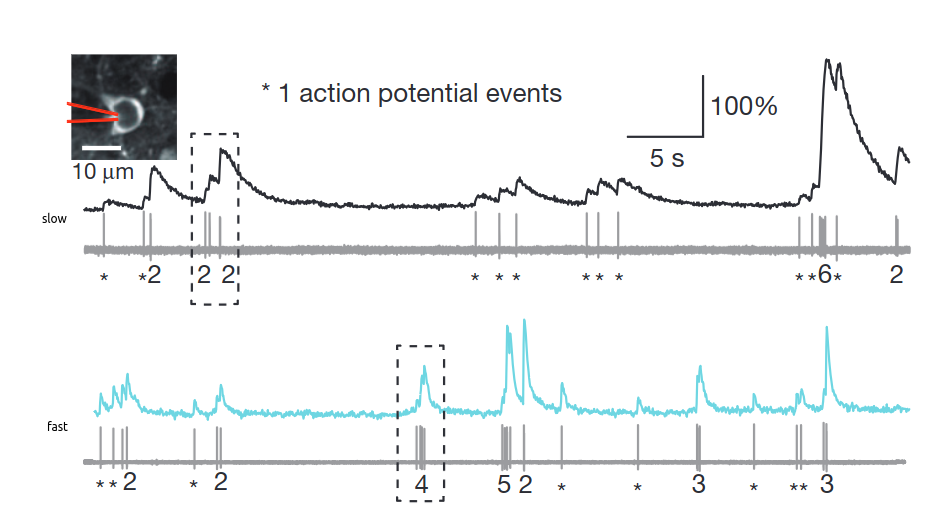

In this notebook you will work with 2 photon calcium recordings from mouse V1 and retina. For details see [Chen et al. 2013](https://www.nature.com/articles/nature12354) and [Theis et al. 2016](https://www.cell.com/neuron/pdf/S0896-6273(16)30073-3.pdf). Two-photon imaging is widely used to study computations in populations of neurons. 

In this exercise sheet we will study properties of different indicators and work on methods to infer spikes from calcium traces. All data is provided at a sampling rate of 100 Hz. For easier analysis, please resample it to 25 Hz. `scipy.signal.decimate` can help here, but note that it is only meant for continous signals. 

__Data__: Download the data file ```nds_cl_3_*.csv``` from ILIAS and save it in a subfolder ```../data/```. Note, some recordings were of shorter duration, hence their columns are padded. 

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal
from __future__ import annotations

%matplotlib inline

%load_ext jupyter_black

%load_ext watermark
%watermark --time --date --timezone --updated --python --iversions --watermark -p sklearn

Last updated: 2026-05-10 18:49:57 W. Europe Daylight Time

Python implementation: CPython
Python version       : 3.13.13
IPython version      : 9.12.0

sklearn: 1.8.0

matplotlib: 3.10.8
numpy     : 2.4.4
pandas    : 3.0.2
scipy     : 1.17.1
seaborn   : 0.13.2

Watermark: 2.6.0



In [3]:
plt.style.use("matplotlib_style.txt")

## Load data

In [4]:
# ogb dataset from Theis et al. 2016 Neuron
ogb_calcium = pd.read_csv("../data/nds_cl_3_ogb_calcium.csv", header=0)
ogb_spikes = pd.read_csv("../data/nds_cl_3_ogb_spikes.csv", header=0)
print(f"[OGB] calcium: {ogb_calcium.shape}, spikes: {ogb_spikes.shape}")

# gcamp dataset from Chen et al. 2013 Nature
gcamp_calcium = pd.read_csv("../data/nds_cl_3_gcamp2_calcium.csv", header=0)
gcamp_spikes = pd.read_csv("../data/nds_cl_3_gcamp2_spikes.csv", header=0)
print(f"[GCaMP] calcium: {gcamp_calcium.shape}, spikes: {gcamp_spikes.shape}")

# spike dataframe
ogb_spikes.head()

[OGB] calcium: (71986, 11), spikes: (71986, 11)
[GCaMP] calcium: (23973, 37), spikes: (23973, 37)


,0,1,2,3,4,5,6,7,8,9,10
0,0,0,0.0,0.0,0,0,0,0.0,0,0.0,0
1,0,0,0.0,0.0,0,1,0,0.0,0,0.0,0
2,0,0,0.0,0.0,0,0,0,0.0,0,0.0,0
3,0,0,0.0,0.0,0,1,0,0.0,0,0.0,0
4,0,0,0.0,0.0,0,0,0,0.0,0,0.0,0


## Task 1: Visualization of calcium and spike recordings

We start again by plotting the raw data - calcium and spike traces in this case. One dataset has been recorded using the synthetic calcium indicator OGB-1 at population imaging zoom (~100 cells in a field of view) and the other one using the genetically encoded indicator GCamp6f zooming in on individual cells. Plot the traces of an example cell from each dataset to show how spikes and calcium signals are related. A good example cell for the OGB-dataset is cell 5. For the CGamp-dataset a good example is cell 6. Align the traces by eye (add a small offset to the plot) such that a valid comparison is possible and zoom in on a small segment of tens of seconds.

*Grading: 3 pts*

In [5]:
ogb_calcium = ogb_calcium.dropna(axis=0)
ogb_spikes = ogb_spikes.dropna(axis=0).to_numpy()

gcamp_calcium = gcamp_calcium.dropna(axis=0)
gcamp_spikes = gcamp_spikes.dropna(axis=0).to_numpy()

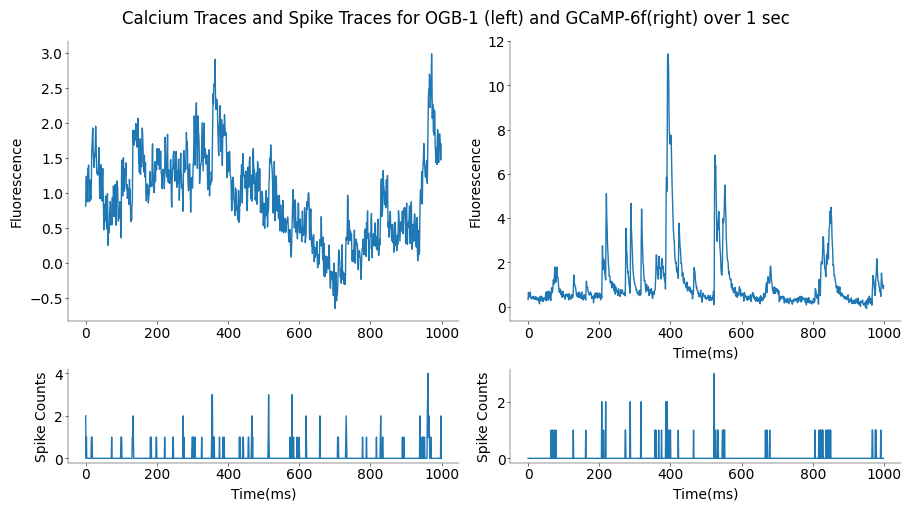

In [6]:
# --------------------------------
# Resample and prepare data (1 pt)
# --------------------------------

resamp_obg = signal.decimate(ogb_calcium, 4, axis=0)
resamp_obg_spikes = np.add.reduceat(
    ogb_spikes, np.arange(0, len(ogb_spikes), 4), axis=0
)

resamp_gcamp = signal.decimate(gcamp_calcium, 4, axis=0)
resamp_gcamp_spikes = np.add.reduceat(
    gcamp_spikes, np.arange(0, len(gcamp_spikes), 4), axis=0
)


fig, axs = plt.subplots(
    2, 2, figsize=(9, 5), height_ratios=[3, 1], layout="constrained"
)

fig.suptitle(
    "Calcium Traces and Spike Traces for OGB-1 (left) and GCaMP-6f(right) over 1 sec"
)
# --------------------
# Plot OGB data (1 pt)
# --------------------

axs[0, 0].plot(resamp_obg[:, 5][:1000])
axs[0, 0].set_ylabel("Fluorescence")
# axs[0,0].set_xlabel("Time(ms)")

axs[1, 0].plot(resamp_obg_spikes[:, 5][:1000])
axs[1, 0].set_ylabel("Spike Counts")
axs[1, 0].set_xlabel("Time(ms)")

# ----------------------
# Plot GCamp data (1 pt)
# ----------------------
axs[0, 1].plot(resamp_gcamp[:, 6][:1000])
axs[0, 1].set_ylabel("Fluorescence")
axs[0, 1].set_xlabel("Time(ms)")

axs[1, 1].plot(resamp_gcamp_spikes[:, 6][:1000])
axs[1, 1].set_ylabel("Spike Counts")
axs[1, 1].set_xlabel("Time(ms)")

plt.show()

## Bonus Task (Optional): Calcium preprocessing

To improve the quality of the inferred spikes, further preprocessing steps can undertaken. This includes filtering and smoothing of the calcium trace.

Implement a suitable filter and local averaging procedure as discussed in the lecture. Explain your choices and discuss how it helps!

_Grading: 1 BONUS point_

_BONUS Points do not count for this individual coding lab, but sum up to 5% of your **overall coding lab grade**. There are 4 BONUS points across all coding labs._

## Task 2: Simple deconvolution

It is clear from the above plots that the calcium events happen in relationship to the spikes. As a first simple algorithm implement a deconvolution approach like presented in the lecture in the function `deconv_ca`. Assume an exponential kernel where the decay constant depends on the indicator ($\tau_{OGB}= 0.5 s$, $\tau_{GCaMP}= 0.1 s$). Note there can be no negative rates! Plot the kernel as well as an example cell with true and deconvolved spike rates. Scale the signals such as to facilitate comparisons. You can use functions from `scipy` for this. Explain your results and your choice of kernel.

*Grading: 5 pts*


In [7]:
def deconv_ca(ca: np.ndarray, tau: float, dt: float) -> np.ndarray:
    """Compute the deconvolution of the calcium signal.

    Parameters
    ----------

    ca: np.array, (n_points,)
        Calcium trace

    tau: float
        decay constant of conv kernel

    dt: float
        sampling interval.

    Return
    ------

    sp_hat: np.array
    """

    # --------------------------------------------
    # apply devonvolution to calcium signal (1 pt)
    # --------------------------------------------

    # low pass filter
    # deconvolution

    # decay factor for the calcium signal =  gamma
    gamma = np.exp(-dt / tau)

    sp_hat = np.zeros_like(ca)

    # spike inference
    for i in range(len(sp_hat) - 1):
        sp_hat[i] = ca[i] - gamma * ca[i - 1]

    # non negative spikes
    sp_hat = np.maximum(sp_hat, 0)

    return sp_hat

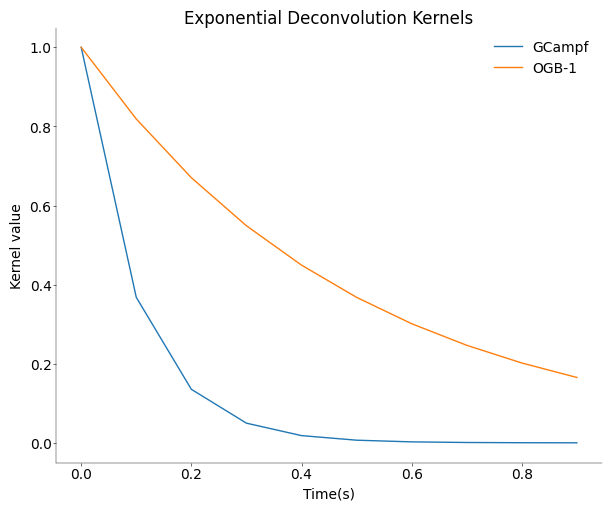

In [8]:
# -------------------------
# Plot the 2 kernels (1 pt)
# -------------------------

tau_gcamp = 0.1
tau_ogb = 0.5
dt = 0.04  # 1/sampling rate

fig, ax = plt.subplots(figsize=(6, 5), layout="constrained")

time = np.arange(0, 1, 0.1)

gcamp = ax.plot(time, np.exp(-time / tau_gcamp), label="GCamp6f")
ogb = ax.plot(time, np.exp(-time / tau_ogb), label="OGB-1")

ax.set_title("Exponential Deconvolution Kernels")
ax.set_ylabel("Kernel value")
ax.set_xlabel("Time(s)")
ax.legend(["GCampf", "OGB-1"])


plt.show()

### Questions (1 pt)
1) Explain how you constructed the kernels

We consider a time frame of 0 to 1 sec for the exponential kernel. Then, we plot the curve of the decay with respect to the decay constant of the respective kernel.

2) How do the indicators / kernels compare?

The OGB-1 indicator has a larger decay constant, so it decays slower than GCaMP-6f., indicated by the gentle slope in the graph. This means that the spikes from OGB-1 would overlap more and it would be harder to distinguish closely spaced spikes.

3) What are pros and cons of each indicator?

- OGB-1: Pros = larger decay constant, fluroscence persists and peaks are easier to detect, Cons = Poorer temporal resolution as nearby spikes might be overlapped. 

- GCaMP-6f: Pros = Better temporal precision with smaller decay constant, nearby spikes are easier to distinguish. Cons = Fluroscence disappears quickly, weak activity might be harder to detect

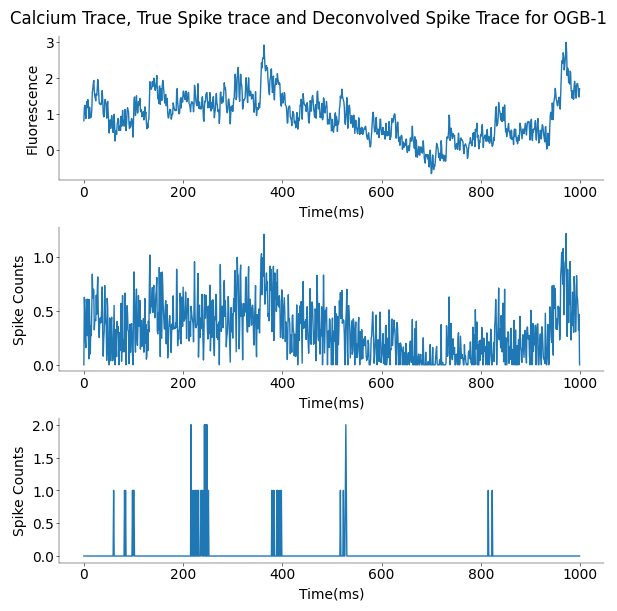

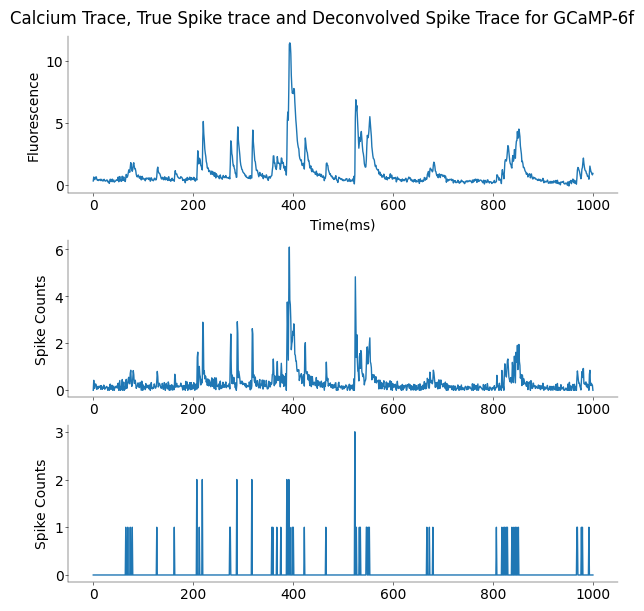

In [10]:
# ----------------------------------------------------------------------
# Compare true and deconvolved spike rates for the OGB and GCamP cells.
# What differences do you notice? Does this align with your knowledge
# about the indicators? (2 pts)
# ----------------------------------------------------------------------


fig, axs = plt.subplots(
    3, 1, figsize=(6, 6), height_ratios=[1, 1, 1], gridspec_kw=dict(hspace=0)
)

fig.suptitle("Calcium Trace, True Spike trace and Deconvolved Spike Trace for OGB-1")
# OGB Cell
deconv_ogb = deconv_ca(resamp_obg[:, 5][:1000], tau_gcamp, dt)

axs[0].plot(resamp_obg[:, 5][:1000])

axs[0].set_ylabel("Fluorescence")
axs[0].set_xlabel("Time(ms)")


axs[1].set_ylabel("Spike Counts")
axs[1].set_xlabel("Time(ms)")
axs[1].plot(deconv_ogb)


axs[2].set_ylabel("Spike Counts")
axs[2].set_xlabel("Time(ms)")
axs[2].plot(resamp_gcamp_spikes[:, 5][:1000])


fig, axs = plt.subplots(
    3, 1, figsize=(6, 6), height_ratios=[1, 1, 1], gridspec_kw=dict(hspace=0)
)
fig.suptitle("Calcium Trace, True Spike trace and Deconvolved Spike Trace for GCaMP-6f")

# GCamp Cell

deconv = deconv_ca(resamp_gcamp[:, 6][:1000], tau_gcamp, dt)

axs[0].plot(resamp_gcamp[:, 6][:1000])
axs[0].set_ylabel("Fluorescence")
axs[0].set_xlabel("Time(ms)")

axs[1].set_ylabel("Spike Counts")
axs[1].plot(deconv)

axs[2].set_ylabel("Spike Counts")
axs[2].plot(resamp_gcamp_spikes[:, 6][:1000])

plt.show()

## Task 3: Run more complex algorithm

As reviewed in the lecture, a number of more complex algorithms for inferring spikes from calcium traces have been developed. Run an implemented algorithm on the data and plot the result. There is a choice of algorithms available, for example:

* Vogelstein: [oopsi](https://github.com/liubenyuan/py-oopsi)
* Theis: [c2s](https://github.com/lucastheis/c2s)
* Friedrich: [OASIS](https://github.com/j-friedrich/OASIS)

*Grading: 3 pts*



In [11]:
# run this cell to download the oopsi.py file and put it in the same folder as this notebook
# !wget https://raw.githubusercontent.com/liubenyuan/py-oopsi/master/oopsi.py
import oopsi

In [12]:
# ----------------------------------------------------------------------
# Apply one of the advanced algorithms to the OGB and GCamp Cells (1 pt)
# ----------------------------------------------------------------------

# implementing oopsi for OGB and GCamp

d_ogb, Cz = oopsi.fast(resamp_obg[:, 5][:1000], dt=dt, iter_max=6, update=True)

d_gcamp, _ = oopsi.fast(resamp_gcamp[:, 6][:1000], dt=dt, iter_max=6, update=True)

c:\Users\janaurmi\OneDrive\Docs\Germany docs\Neural DS\nds_env\notebooks\oopsi.py:112: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  d = linsolve.spsolve(H, g)  # direction to step


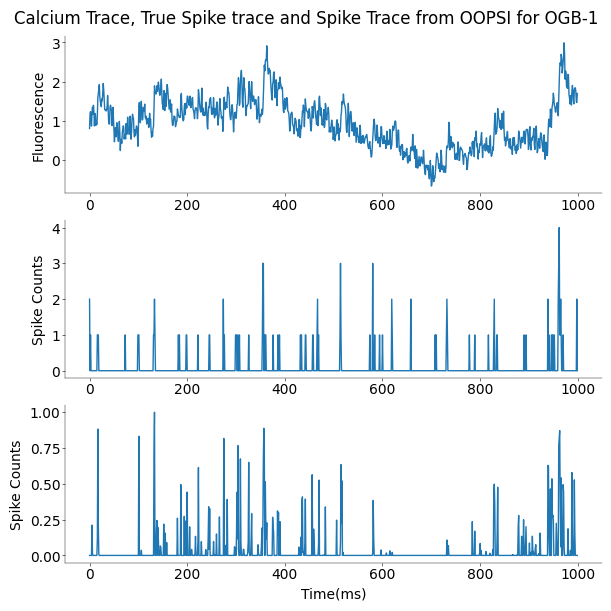

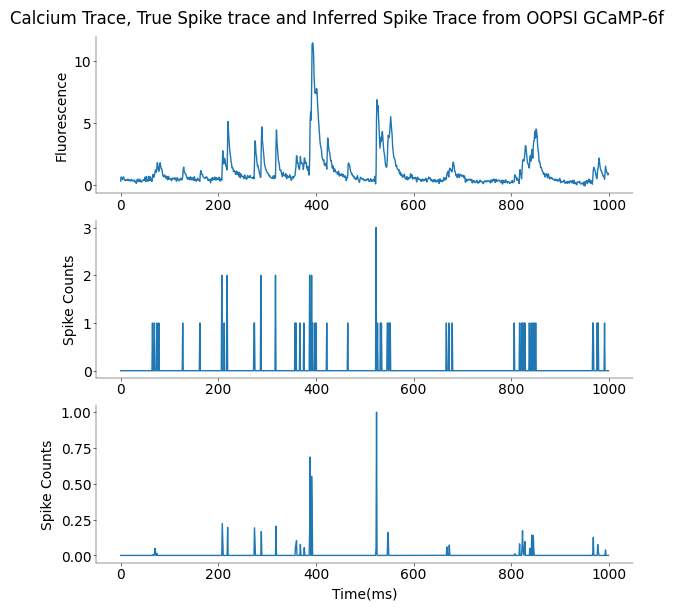

In [13]:
# -------------------------------------------------------------------------------
# Plot the results for the OGB and GCamp Cells and describe the results (1+1 pts)
# -------------------------------------------------------------------------------

fig, axs = plt.subplots(
    3, 1, figsize=(6, 6), height_ratios=[1, 1, 1], gridspec_kw=dict(hspace=0)
)
fig.suptitle("Calcium Trace, True Spike trace and Spike Trace from OOPSI for OGB-1")
# OGB Cell

axs[0].set_ylabel("Fluorescence")
axs[0].plot(resamp_obg[:, 5][:1000])

axs[1].set_ylabel("Spike Counts")
axs[1].plot(resamp_obg_spikes[:, 5][:1000])

axs[2].set_ylabel("Spike Counts")
axs[2].set_xlabel("Time(ms)")
axs[2].plot(d_ogb)

fig, axs = plt.subplots(
    3, 1, figsize=(6, 6), height_ratios=[1, 1, 1], gridspec_kw=dict(hspace=0)
)

fig.suptitle(
    "Calcium Trace, True Spike trace and Inferred Spike Trace from OOPSI GCaMP-6f"
)

# GCamP Cell
axs[0].set_ylabel("Fluorescence")
axs[0].plot(resamp_gcamp[:, 6][:1000])


axs[1].set_ylabel("Spike Counts")
axs[1].plot(resamp_gcamp_spikes[:, 6][:1000])

axs[2].set_ylabel("Spike Counts")
axs[2].set_xlabel("Time(ms)")
axs[2].plot(d_gcamp)

## Task 4: Evaluation of algorithms

To formally evaluate the algorithms on the two datasets run the deconvolution algorithm and the more complex one on all cells and compute the correlation between true and inferred spikes. `DataFrames` from the `pandas` package are a useful tool for aggregating data and later plotting it. Create a dataframe with columns

* algorithm
* correlation
* indicator

and enter each cell. Plot the results using `stripplot` and/or `boxplot` in the `seaborn` package. Note these functions provide useful options for formatting the
plots. See their documentation, i.e. `sns.boxplot?`.

*Grading: 5 pts*


First, evaluate on OGB data and create OGB dataframe. Then repeat for GCamp and combine the two dataframes.

In [21]:
# ----------------------------------------------------------
# Evaluate the algorithms on the OGB and GCamp cells (2 pts)
# ----------------------------------------------------------

results = []

# --- Evaluate OGB Population ---
for i in range(resamp_obg.shape[1]):
    # Ground truth spikes
    true_sp = resamp_obg_spikes[:, i]

    # 1. Simple Deconvolution
    sp_deconv = deconv_ca(resamp_obg[:, i], tau_ogb, dt)
    # Correlation
    c_deconv = np.corrcoef(true_sp, sp_deconv)[0, 1]
    results.append({"algorithm": "deconv", "correlation": c_deconv, "indicator": "OGB"})

    # 2. oopsi Inference
    sp_oopsi, _ = oopsi.fast(resamp_obg[:, i], dt=dt)
    c_oopsi = np.corrcoef(true_sp, sp_oopsi)[0, 1]
    results.append({"algorithm": "oopsi", "correlation": c_oopsi, "indicator": "OGB"})

# --- Evaluate GCaMP Population ---
for i in range(resamp_gcamp.shape[1]):
    true_sp = resamp_gcamp_spikes[:, i]

    # 1. Simple Deconvolution
    sp_deconv = deconv_ca(resamp_gcamp[:, i], tau_gcamp, dt)
    c_deconv = np.corrcoef(true_sp, sp_deconv)[0, 1]
    results.append(
        {"algorithm": "deconv", "correlation": c_deconv, "indicator": "GCaMP"}
    )

    # 2. oopsi Inference
    sp_oopsi, _ = oopsi.fast(resamp_gcamp[:, i], dt=dt)
    c_oopsi = np.corrcoef(true_sp, sp_oopsi)[0, 1]
    results.append({"algorithm": "oopsi", "correlation": c_oopsi, "indicator": "GCaMP"})

c:\Users\janaurmi\OneDrive\Docs\Germany docs\Neural DS\nds_env\notebooks\oopsi.py:112: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  d = linsolve.spsolve(H, g)  # direction to step


Combine both dataframes. Plot the performance of each indicator and algorithm. You should only need a single plot for this.

In [25]:
# ---------------------------------------------------------------------------------
# Construct the dataframe and print the first few rows as well as its shape (1 pts)
# ---------------------------------------------------------------------------------
df_results = pd.DataFrame(results)
print(df_results.head())
print(f"\nDataframe shape: {df_results.shape}")

  algorithm  correlation indicator
0    deconv     0.257308       OGB
1     oopsi     0.339886       OGB
2    deconv     0.088592       OGB
3     oopsi     0.223293       OGB
4    deconv     0.088898       OGB

Dataframe shape: (96, 3)


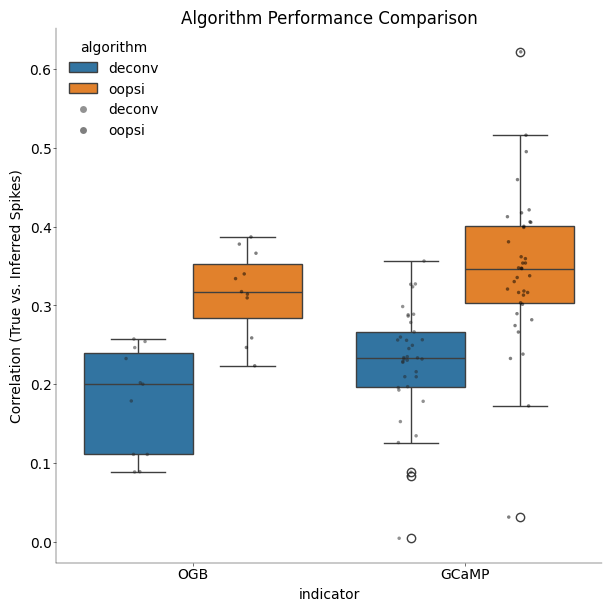

In [26]:
# ----------------------------------------------------------------------------
# Create Strip and Boxplot for both cells and algorithms Cell as described. (1 pt)
# Describe and explain the results briefly. (1 pt)
# ----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6, 6), layout="constrained")


sns.boxplot(data=df_results, x="indicator", y="correlation", hue="algorithm")
sns.stripplot(
    data=df_results,
    x="indicator",
    y="correlation",
    hue="algorithm",
    dodge=True,
    alpha=0.5,
    palette="dark:black",
)
plt.title("Algorithm Performance Comparison")
plt.ylabel("Correlation (True vs. Inferred Spikes)")
plt.show()

GCaMP6f is the winner for accuracy. OGB-1 is much slower. Because it takes 
 to reset, the signals from several spikes often blur together into one big lump.

opsi is smarter than simple deconvolution. allows it to ignore the random background noise and focus only on the real signals, leading to higher correlation scores across almost all cells.

GCaMP6f combined with the oopsi algorithm gives you the most realistic and accurate estimate of when the neuron is actually firing.